<a href="https://colab.research.google.com/github/adapasriram/US_HONEY_PRODUCTION/blob/main/Airbnb_Case_Study02_06_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Airbnb is an online platform that connects people who have places to stay(hosts) with peoplw looking for accommodation(guests).

# **Business Problem:**

1. **Hosts and Area:** What can we learn about different Airbnb Hosts and the area they list in?

2. **Predictions:** Can we guess things like price, numbers of reviews and popularity based on the data?

3. **Busiest Host:** Who are the most active host and who do they get so many bookings?

4. **Traffic Differences:** Are some areas busier than others? What might be the reason?

In [ ]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load the Dataset
df=pd.read_csv('/content/Airbnb_data.csv')

In [ ]:
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


id: Unique ID of the Airbnb Listings

name: Name of the Airbnb Listings property.

host_id: Unique id of the host.

host_name: Name of the host.

neighbourhood_group:The larger area

neighbourhood:The smaller area inside that larger area.

latitude: Latitude cordinate of the property

longitude: Logitude cordinate of the property.

room_type: Type of room(eg-Private room, shared room,entire apt).

price: Price of the property(in USD).

minimum_nights: Minimum number of nights guests are required to stay.

number_of_reviews: Number of the reviews the property rececived.

Last review: Date of the last review.

reviews_per_month: AVerage number of reviwes per month.

calculated_host_listings_count: Total number of properties listed by a host.

availability_365: Number of days the property is avialble in a year.

# **Data Inspection:**

In [ ]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


# **Insights:**

Some column name we should rename it as they are confusing.

In [ ]:
rename_col={'id':'property_id','name':'property_name','number_of_reviews':'total_reviews','calculated_host_listings_count':'host_listing_count'}

In [ ]:
df.rename(columns=rename_col,inplace=True)

In [ ]:
df.head()

,property_id,property_name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,total_reviews,last_review,reviews_per_month,host_listing_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_id          48895 non-null  int64  
 1   property_name        48879 non-null  object 
 2   host_id              48895 non-null  int64  
 3   host_name            48874 non-null  object 
 4   neighbourhood_group  48895 non-null  object 
 5   neighbourhood        48895 non-null  object 
 6   latitude             48895 non-null  float64
 7   longitude            48895 non-null  float64
 8   room_type            48895 non-null  object 
 9   price                48895 non-null  int64  
 10  minimum_nights       48895 non-null  int64  
 11  total_reviews        48895 non-null  int64  
 12  last_review          38843 non-null  object 
 13  reviews_per_month    38843 non-null  float64
 14  host_listing_count   48895 non-null  int64  
 15  availability_365     48895 non-null 

# **Insights:**

The columns that are property name, host name, last review, reviews per month these columns are having some null values.


In [ ]:
df.isnull().sum()

,0
property_id,0
property_name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
df.property_name.fillna('unknown',inplace=True)
df.host_name.fillna('unknown',inplace=True)

/tmp/ipykernel_470/1386849901.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.host_name.fillna('unknown',inplace=True)


In [ ]:
df.isnull().sum()

,0
property_id,0
property_name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
df.drop('last_review',axis=1,inplace=True)

In [ ]:
df.isnull().sum()

,0
property_id,0
property_name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
df.reviews_per_month=df.reviews_per_month.replace(to_replace=np.nan,value=0).astype('int64')

In [ ]:
df.isnull().sum()

,0
property_id,0
property_name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# **Basic Understanding of the Data:**



**Q1. How many unique property we are having in the New York City?**

In [ ]:
#nunique
a=df.property_id.nunique()
print('The total number of unique property we are having in the New York City:',a)

The total number of unique property we are having in the New York City: 48895


**Q2. How many unique neighbourhood we are havinng in New York City?**

In [ ]:
b=df.neighbourhood.nunique()
print('The total number of unique neighbourhood we are having in the New York City:',b)

The total number of unique neighbourhood we are having in the New York City: 221


**Q3. How many Unique neighbourhood Group we are having in New York City?**

In [ ]:
c=df.neighbourhood_group.nunique()
print('The total number of unique neighbourhood group we are having in the New York City:',c)

The total number of unique neighbourhood group we are having in the New York City: 5


**Q4. How many unique hosts we are having in New York City?**

In [ ]:
d=df.host_id.nunique()
print('The total number of unique hosts we are having in the New York City:',d)

The total number of unique hosts we are having in the New York City: 37457


**Q5. How many unique peoperty name we are having in New York City?**

In [ ]:
e=df.property_name.nunique()
print('The total number of unique property name we are having in the New York City:',e)

The total number of unique property name we are having in the New York City: 47906


# **Insights:**

In our NYC, we are having 5 neighbourhood group in total that consist of 221 neighbbours in this we have total 37457 hosts wchih owns 48895 properties.

Majority of Hosts have multiple properties.

# **Statistical Analysis:**



In [ ]:
df.describe()

,property_id,host_id,latitude,longitude,price,minimum_nights,total_reviews,reviews_per_month,host_listing_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,0.806258,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.502767,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.000000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.000000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,1.000000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.000000,327.000000,365.000000


# **Insights:**

The average price of staying one night is 152 dollars.

25% of the properties are located at logitude and latitude 40.69 and --73.9.

The average night a person stays in Airbnbb is 7 days(high).

The most expensive property on airbnb is 10000 dollars.

The average review that a property has got is 23.

The maximum nigghts a  person stays is 1250.

In [ ]:
df.describe(include='object')

,property_name,host_name,neighbourhood_group,neighbourhood,room_type
count,48895,48895,48895,48895,48895
unique,47906,11453,5,221,3
top,Hillside Hotel,Michael,Manhattan,Williamsburg,Entire home/apt
freq,18,417,21661,3920,25409


# **Insights:**

The airbnbb that is most popular is Hillside Hotel.

Manhattan is most popular neighbourhood group.

Micheal is the most popular/busiest host in airbnb.

Most people like Entire home/apt.

Most popular neighbourhood is Williamsburg.


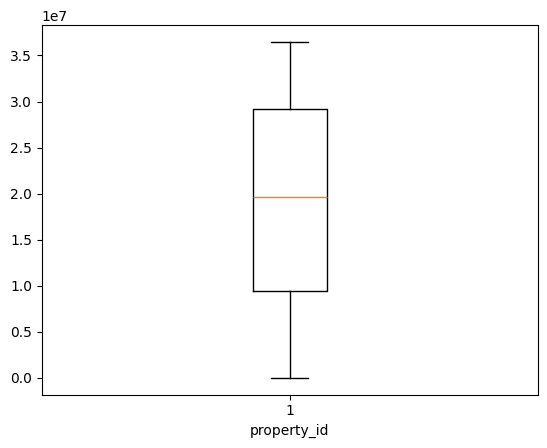

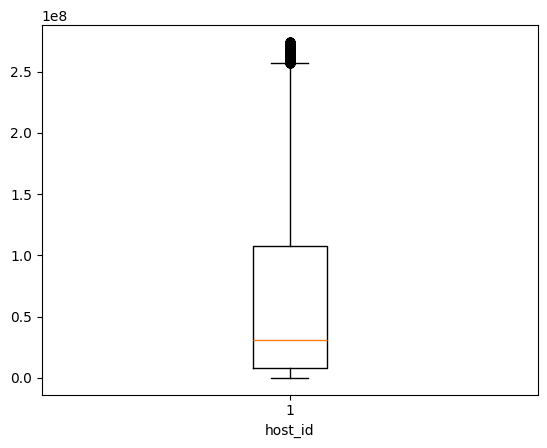

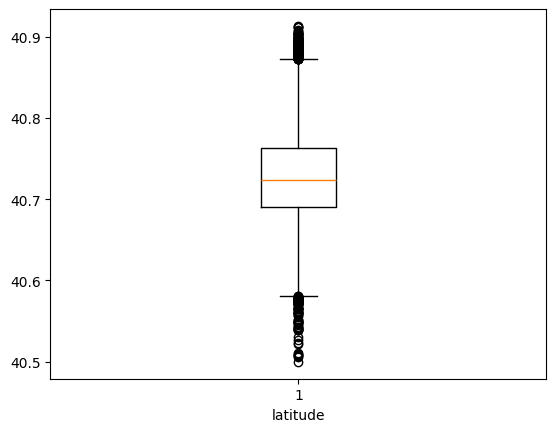

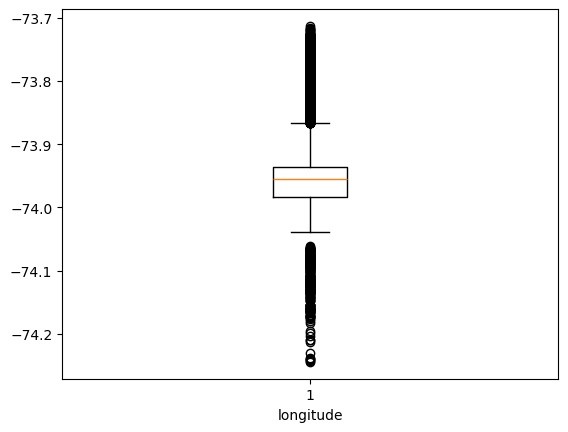

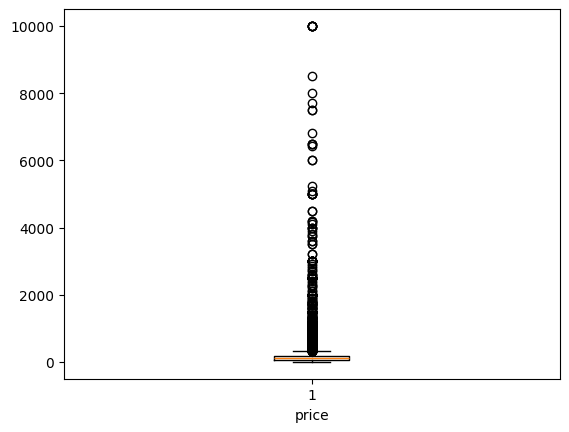

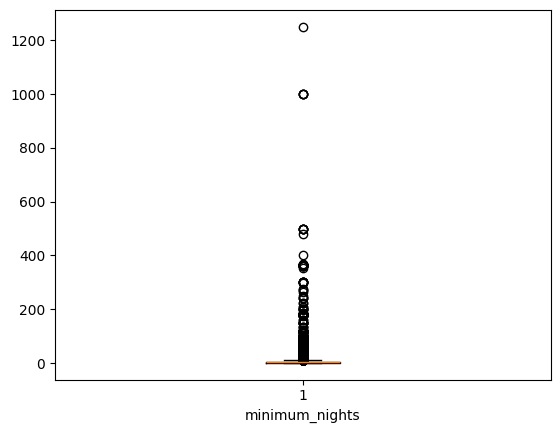

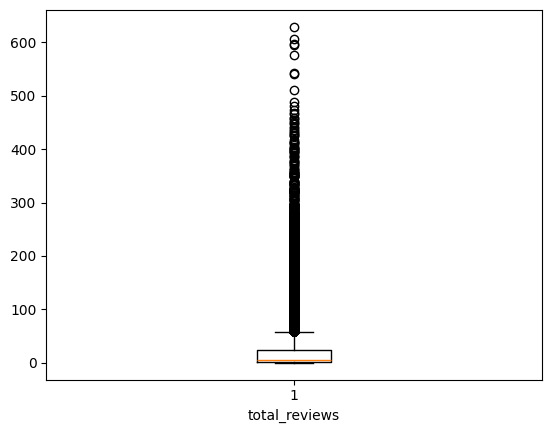

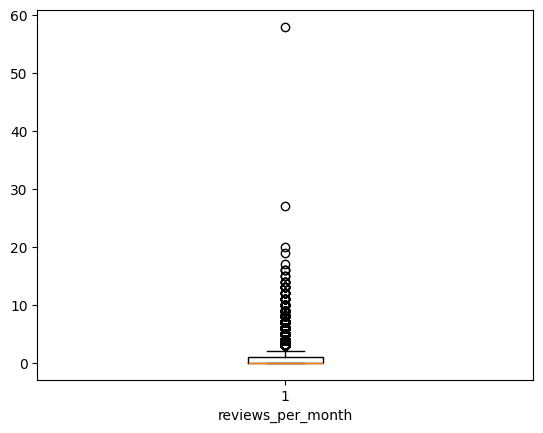

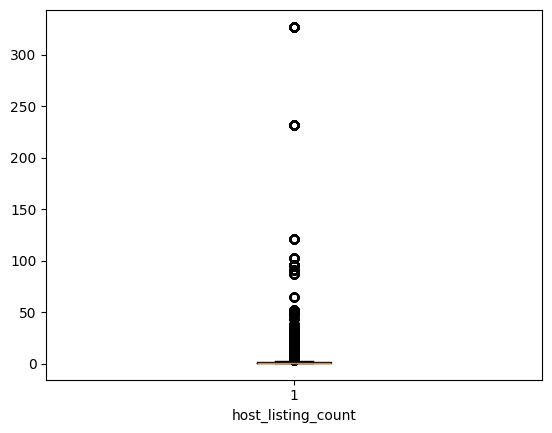

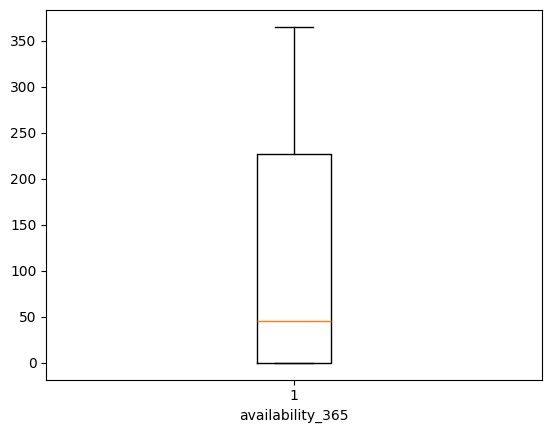

In [ ]:
#outliers:
for i in df.columns:
  if df[i].dtype!='object':
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

In [ ]:
#Eliminate the outlier
def iqr_sol(col):
  q1=np.percentile(col,25)
  q3=np.percentile(col,75)

  iqr=q3-q1
  LL=q1-1.5*iqr
  UL=q3+1.5*iqr

  return UL,LL

In [ ]:
UL,LL=iqr_sol(df['price'])

In [ ]:
print(UL,LL)

334.0 -90.0


In [ ]:
df=df[(df.price>LL)& (df.price<UL)]

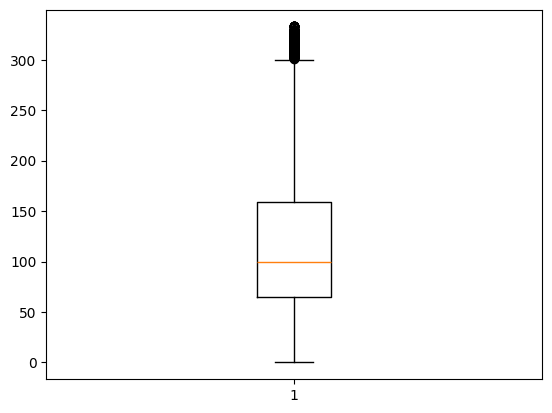

In [ ]:
plt.boxplot(df['price'])
plt.show()

In [ ]:
df.shape

(45918, 15)

# **Visualisations:**



**What is the distribution of the price ranges in the data?(plot a histogram)**

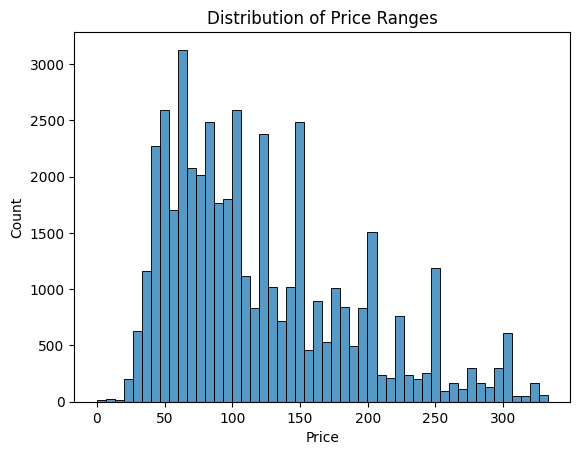

In [ ]:
sns.histplot(df['price'],bins=50)
plt.title('Distribution of Price Ranges')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

# **Insight:**

Data is Right skewed.

Max Price we have between 50-100.

Median Price in the range 100-150.

**Which is the most busiest neighbourhood group?(Plot a countplot)**

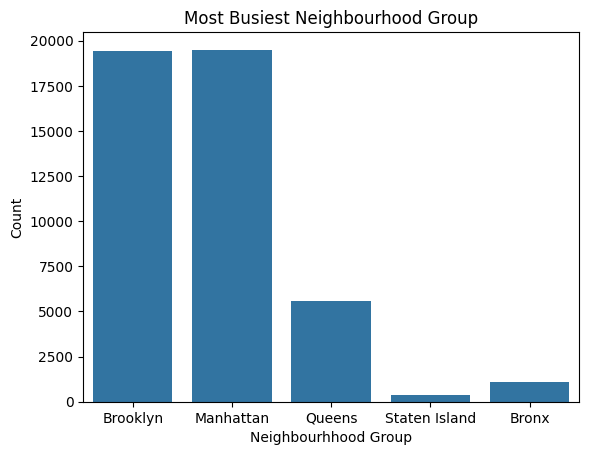

In [ ]:
sns.countplot(x=df['neighbourhood_group'])
plt.title('Most Busiest Neighbourhood Group')
plt.xlabel('Neighbourhhood Group')
plt.ylabel('Count')
plt.show()

# **Insight:**

Manhatan is the most busiest Neigghbourhood Group.

**What is the count of each room Type?(Plot a countplot)**

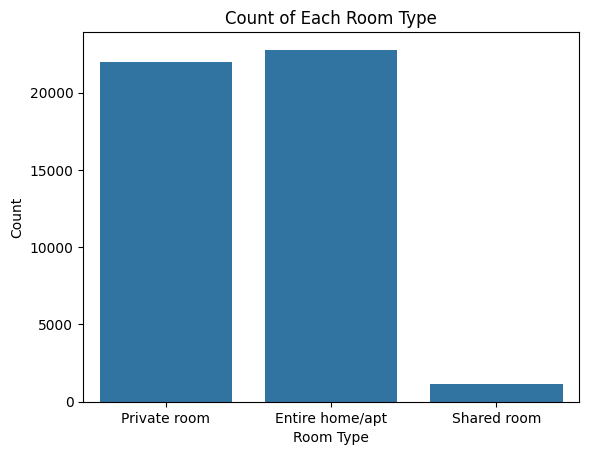

In [ ]:
sns.countplot(x=df['room_type'])
plt.title('Count of Each Room Type')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

# **Insight:**

Entire room/apt is having the most number of count.

**Plot the correlation heatmap to show the relationship between all the columns.**

In [ ]:
#Homework